# Random Seed

In [2]:
import random
import torch
import numpy as np
import json

def set_seed(seed):
    # 設定 Python 隨機數生成器的種子
    random.seed(seed)
    
    # 設定 numpy 隨機數生成器的種子
    np.random.seed(seed)
    
    # 設定 PyTorch 隨機數生成器的種子
    torch.manual_seed(seed)
    
    # 如果使用 GPU，設置 CUDA 隨機數生成器的種子
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    # 設置 PyTorch 預測模式，保證可重現性
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 設定隨機種子
set_seed(22)


## Dataset

In [3]:
from transformers import AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-pretrain")

# 設定預設值
CLASSIFICATION_MISSING_VALUE = -100
NUMERIC_MISSING_VALUE = torch.finfo(torch.float32).max  # 3.4028235e+38

In [4]:
# batch
from concurrent.futures import ThreadPoolExecutor
import math
from tqdm import tqdm

def process_batch(batch, target_attrs, tokenizer):

    batch_results = []
    for job in batch:
        context_p = job['context'].get("context_p", "")
        context_t = job['context'].get("context_t", "")
        context_n = job['context'].get("context_n", "")
        # full_context = f"{context_t} [SEP] {context_p} [SEP] {context_n}"
        document_info = f"{job['document']['document_type']};{job['document']['period_end_date']};{job['document']['fiscal_year']};{job['document']['period_focus']}"
        full_context = f"{context_t} [SEP] {document_info} [SEP] {context_p} [SEP] {context_n}"

        tokenized = tokenizer(
            full_context,
            padding = "max_length",
            truncation = True,
            max_length = 512,
            return_tensors = "pt",
            return_offsets_mapping = True,
            return_special_tokens_mask = True,
        )

        token_ids = tokenized["input_ids"].squeeze(0)
        offset_mapping = tokenized["offset_mapping"].squeeze(0)

        # sep_indices = [idx for idx, token in enumerate(token_ids) if token == tokenizer.sep_token_id]
        # context_t_end = sep_indices[0] if sep_indices else len(token_ids) - 1
        
        for i, target in enumerate(job['targets']):
            start_char, end_char = target['start_pos'], target['end_pos']
            start_token, end_token = -1, -1

            for idx, (start, end) in enumerate(offset_mapping):
                # if idx > context_t_end:
                #     break
                if start <= start_char < end:
                    start_token = idx
                if start < end_char <= end:
                    end_token = idx
                    break
            
            # if start_token == -1 or end_token == -1 or start_token > context_t_end or end_token > context_t_end:
            if start_token == -1 or end_token == -1:
                continue 
                
            # print("\n=== DEBUG: Tokenization ===")
            # token_ids = tokenized["input_ids"].squeeze(0) 
            # tokens = tokenizer.convert_ids_to_tokens(token_ids.tolist())
            # print("Original Text:", full_context)
            # # print("Tokens:", tokens)
            # print("Offset Mapping:", offset_mapping)
            # print(f"Target Text: {target['text']} | Start Char: {start_char}, End Char: {end_char}")
            # print(f"Found Token Indices -> Start: {start_token}, End: {end_token}")
            # if start_token >= 0 and end_token >= 0:
            #     print(f"Matched Tokens: {tokens[start_token:end_token+1]}")
            # print("====================================\n")
            
            target_data = {
                "job_id": job["job_id"],
                "seq_id": target["seq_id"],
                "context": full_context,
                "input_ids": token_ids,
                "attention_mask": tokenized['attention_mask'].squeeze(0),
                "start_token": start_token,
                "end_token": end_token,
                "value": convert_span_to_number(target['text']),
                "doc_link": job['document']['document_link'],
            }
            
            for attr in target_attrs:
                if attr in ["tag", "time", "scale", "negative"]:  # 分類屬性
                    target_data[attr] = CLASSIFICATION_MISSING_VALUE
                elif attr == "fact":  # 數值屬性
                    target_data[attr] = NUMERIC_MISSING_VALUE

            gold_values = job['golds'][i]['value']
            for attr_idx, attr in enumerate(target['attribute']):
                value = gold_values[attr_idx]
                if attr == 'tag':
                    # 暫時先歸到 standard_rare 
                    if value in standard_rare_tags:
                        value = 'standard_rare'
                    target_data['tag'] = tag2id.get(value, -100)
                elif attr == 'time':
                    target_data['time'] = time2id.get(value, -100)
                elif attr == 'fact':
                    if value:
                        target_data['fact'] = float(value)
                        target_data['negative'] = 1 if value < 0 else 0
                    else:
                        target_data['fact'] = NUMERIC_MISSING_VALUE
                        target_data['negative'] = CLASSIFICATION_MISSING_VALUE
                    # target_data['fact'] = float(value)
                elif attr == 'scale':
                    target_data['scale'] = scale2id.get(value, -100)

               
                    
            batch_results.append(target_data)
    return batch_results

from concurrent.futures import ProcessPoolExecutor, TimeoutError


def process_batch_wrapper(args):
    """ 用於 `ProcessPoolExecutor` 的批次處理函數 """
    batch, target_attrs, tokenizer = args
    return process_batch(batch, target_attrs, tokenizer)

def process_data(data, target_attrs, tokenizer, batch_size = 32, num_workers = 8):
    inputs = []
    
    # 計算總批次數
    num_batches = math.ceil(len(data) / batch_size)

    # 將數據拆分成批次
    batches = [data[i * batch_size: (i + 1) * batch_size] for i in range(num_batches)]

    # 構建參數列表
    task_args = [(batch, target_attrs, tokenizer) for batch in batches]

    # 使用多進程處理批次
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(tqdm(executor.map(process_batch_wrapper, task_args), total=num_batches, desc="Processing Data"))

    # 合併所有批次的結果
    for res in results:
        inputs.extend(res)
    
    return inputs


In [5]:
# IterableDataset

with open('processed_data_task1/counter/tag_count_train_data.json', 'r', encoding = 'utf-8') as file:
# with open('processed_data_task1_smaller/counter/tag_count_train_400k.json', 'r', encoding = 'utf-8') as file:
# with open('processed_iterable_dataset/counter/train_8k.json', 'r', encoding = 'utf-8') as file:
    tag_counter = json.load(file)
    
# 想讓數量多的類別在前面

tag_counter = dict(sorted(tag_counter.items(), key = lambda item:item[1], reverse=True))

count_threshold = 10
standard_rare_tags = {tag for tag, count in tag_counter.items() if count < count_threshold}
tag_list = [tag for tag in tag_counter.keys() if tag not in standard_rare_tags]
print(tag_list[:5])
print(f'Length of standard_rare_tags: {len(standard_rare_tags)}')
print(f'Length of all tags: {len(tag_list)}')

id2tag = {idx: tag for idx, tag in enumerate(tag_list)}
tag2id = {tag: idx for idx, tag in enumerate(tag_list)}

time_list = ['instant; past', 'instant; current', 'instant; future', 'period; past', 'period; current', 'period; future', 'period; past_current', 'period; current_future', 'period; past_future']
id2time = {idx: time for idx, time in enumerate(time_list)}
time2id = {time: idx for idx, time in enumerate(time_list)}

scale_list = [str(i) for i in range(-12, 13)]
id2scale = {idx: scale for idx, scale in enumerate(scale_list)}
scale2id = {scale: idx for idx, scale in enumerate(scale_list)}
# with open('processed_data_task1_smaller/counter/train_100k.json')

['custom', 'standard_rare', 'us-gaap:DebtInstrumentInterestRateStatedPercentage', 'us-gaap:DebtInstrumentBasisSpreadOnVariableRate1', 'us-gaap:DebtInstrumentFaceAmount']
Length of standard_rare_tags: 0
Length of all tags: 978


In [6]:
import locale
from word2number import w2n

def convert_span_to_number(span):
    """
    將 span 轉換為數字。
    """
    span = span.strip()
    
    # 嘗試直接轉換為數字
    try:
        return locale.atof(span.replace(",", ""))  # 去掉千分位逗號並轉換
    except ValueError:
        pass  # 不是標準數字，繼續嘗試解析
    
    # 嘗試將文字轉為數字
    try:
        return w2n.word_to_num(span.lower())
    except ValueError:
        pass  # 不是可解析的數字
    
    return None  # 解析失敗，返回 None


#### IterableDataset

In [7]:
import random
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class MultiTaskIterableDataset(IterableDataset):
    ''' 讀取原始 JSONL 檔案，進行前處理'''

    def __init__(self, files, target_attrs, tokenizer, batch_size=32, num_workers=8):
        self.files = files
        self.target_attrs = target_attrs
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.num_workers = num_workers
    
    def _get_sharded_lines(self, file_path):
        """確保多進程時，每個 worker 讀不同的部分"""
        worker_info = get_worker_info()
        if worker_info is None:  # 單進程模式
            start, step = 0, 1
        else:
            start, step = worker_info.id, worker_info.num_workers  # worker id & 總數

        with open(file_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i % step == start:  # 讓不同 worker 讀不同的行
                    yield line
    def __iter__(self):
        """逐行讀取 JSONL 並轉換為數據格式"""
        for file_path in self.files:
            for line in self._get_sharded_lines(file_path):
                raw_data = json.loads(line)
                processed_data = process_batch([raw_data], self.target_attrs, self.tokenizer)
                for item in processed_data:
                    yield item
                    
class BufferedShuffleDataset(IterableDataset):
    """ 負責對 IterableDataset 進行 buffer shuffle """

    def __init__(self, dataset, buffer_size = 8000):
        self.dataset = dataset
        self.buffer_size = buffer_size

    def __iter__(self):
        buffer = []
        for sample in self.dataset:
            buffer.append(sample)
            if len(buffer) >= self.buffer_size:
                random.shuffle(buffer)
                while buffer:
                    yield buffer.pop()

        random.shuffle(buffer)
        while buffer:
            yield buffer.pop()

In [7]:
# buffer_size = 8000
batch_size = 64
num_workers = 4
target_attrs = ["tag", "time", "scale", "negative", "fact"]
train_dataset = MultiTaskIterableDataset(
    # files = [f'processed_data_task1/train_split/train_data_part_{i}.jsonl' for i in range(6)], 
    files = ["processed_data_task1/train_data_shuffled.jsonl"],
    target_attrs = target_attrs,
    tokenizer = tokenizer)

# 只有 training set 進行 shuffle
# train_shuffled_dataset = BufferedShuffleDataset(train_dataset, buffer_size)


valid_dataset = MultiTaskIterableDataset(
    files = ["processed_data_task1/valid_data.jsonl"], 
    target_attrs = target_attrs,
    tokenizer = tokenizer)

test_dataset = MultiTaskIterableDataset(
    files = ["processed_data_task1/test_data.jsonl"], 
    target_attrs = target_attrs,
    tokenizer = tokenizer)


train_dataloader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, num_workers=num_workers)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers)

In [8]:
# 先把 MultiTaskIterableDataset 轉換為 JSONL
import json

def save_iterable_dataset(output_file, dataloader, approx_num=None):
    with open(output_file, "w", encoding="utf-8") as f:
        for item in tqdm(dataloader, desc=f"Processing {output_file}", total=approx_num):
        # for item in dataloder:
            for i in range(len(item["input_ids"])):  # `item` 是 batch
                json_obj = {}
                for key in item:
                    value = item[key][i]
                    
                    # 檢查是否為 Tensor，轉成 list
                    if isinstance(value, torch.Tensor):
                        json_obj[key] = value.tolist()
                    else:
                        json_obj[key] = value  # 直接儲存非 Tensor 型態 (如 str, int)
    
                f.write(json.dumps(json_obj) + "\n")

# save_iterable_dataset('processed_iterable_dataset/train_400k.jsonl', train_dataloader)
# save_iterable_dataset('processed_iterable_dataset/valid_50k.jsonl', valid_dataloader)
# save_iterable_dataset('processed_iterable_dataset/test_50k.jsonl', test_dataloader)
save_iterable_dataset('processed_iterable_dataset/train_full.jsonl', train_dataloader)
save_iterable_dataset('processed_iterable_dataset/valid_full.jsonl', valid_dataloader)
save_iterable_dataset('processed_iterable_dataset/test_full.jsonl', test_dataloader)

Processing processed_iterable_dataset/train_full.jsonl: 150218it [1:00:34, 41.33it/s]
Processing processed_iterable_dataset/valid_full.jsonl: 17716it [07:09, 41.29it/s]
Processing processed_iterable_dataset/test_full.jsonl: 21485it [08:41, 41.21it/s]


#### Load Processed Iterable Dataset

In [8]:
# 讀取處理後的 JSONL

import json
import torch
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class ProcessedIterableDataset(IterableDataset):
    def __init__(self, files):
        self.files = files

    def _get_sharded_lines(self, file_path):
        """確保多進程時，每個 worker 讀不同的部分"""
        worker_info = get_worker_info()
        if worker_info is None:  # 單進程模式
            start, step = 0, 1
        else:
            start, step = worker_info.id, worker_info.num_workers  # worker id & 總數

        with open(file_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i % step == start:  # 讓不同 worker 讀不同的行
                    yield line

    def __iter__(self):
        """讀取 JSONL 並轉換為合適格式"""
        sample_count = 0
        for file_path in self.files:
            for line in self._get_sharded_lines(file_path):
                raw_data = json.loads(line)

                # 把 list 轉回 torch.Tensor
                processed_data = {
                    key: torch.tensor(value) if isinstance(value, list) else value
                    for key, value in raw_data.items()
                }
                
                yield processed_data

            

# train_files = ["processed_iterable_dataset/train_400k.jsonl"]
# valid_files = ["processed_iterable_dataset/valid_50k.jsonl"]
# test_files = ["processed_iterable_dataset/test_50k.jsonl"]
train_files = ["processed_iterable_dataset/train_full.jsonl"]
valid_files = ["processed_iterable_dataset/valid_full.jsonl"]
test_files = ["processed_iterable_dataset/test_full.jsonl"]

train_dataset = ProcessedIterableDataset(train_files)

valid_dataset = ProcessedIterableDataset(valid_files)

test_dataset = ProcessedIterableDataset(test_files)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=4)

In [9]:
import os

def count_lines(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return sum(1 for _ in f)

# 計算訓練資料大約的 batch 數
train_total_samples = sum(count_lines(f) for f in train_files)
train_approx_batches = train_total_samples // batch_size

valid_total_samples = sum(count_lines(f) for f in valid_files)
valid_approx_batches = valid_total_samples // batch_size

test_total_samples = sum(count_lines(f) for f in test_files)
test_approx_batches = test_total_samples // batch_size


print(f"Train 預計數量: {train_total_samples}, 預計 {train_approx_batches} 個 batch")
print(f"Valid 預計數量: {valid_total_samples}, 預計 {valid_approx_batches} 個 batch")
print(f"Test 預計數量: {test_total_samples}, 預計 {test_approx_batches} 個 batch")

Train 預計數量: 9613848, 預計 150216 個 batch
Valid 預計數量: 1133729, 預計 17714 個 batch
Test 預計數量: 1374867, 預計 21482 個 batch


## Count

#### 計算 tag, scale, negative, time 的類別個數
計算後存成 JSON，之後可以直接用

In [11]:
from collections import Counter
import json

def count_classes_in_jsonl(file_paths, target_path, target_attr="tag"):
    class_counts = Counter()
    for file_path in file_paths:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                data = json.loads(line)
                class_counts[data[target_attr]] += 1
                
    target_file = f'{target_path}_{target_attr}.json'
    
    with open(target_file, 'w', encoding = 'utf-8') as f:
        json.dump(class_counts, f, ensure_ascii=False, indent=4)
    
    print(f"{target_attr} count save to {target_file}")
    
    return class_counts

# train_size = 8
# train_files = [f"processed_iterable_dataset/train_{train_size}k.jsonl"]
# target_path = f'processed_iterable_dataset/counter/train_{train_size}k'

train_files = [f"processed_iterable_dataset/train_full.jsonl"]
target_path = f'processed_iterable_dataset/counter/train_full'

train_tag_counts = count_classes_in_jsonl(train_files, target_path, "tag")
train_time_counts = count_classes_in_jsonl(train_files, target_path, "time")
train_neg_counts = count_classes_in_jsonl(train_files, target_path, "negative")
train_scale_counts = count_classes_in_jsonl(train_files, target_path, "scale")

tag count save to processed_iterable_dataset/counter/train_full_tag.json
time count save to processed_iterable_dataset/counter/train_full_time.json
negative count save to processed_iterable_dataset/counter/train_full_negative.json
scale count save to processed_iterable_dataset/counter/train_full_scale.json


In [10]:
# load counter result

def load_counter(target_path, target_attr):
    target_file = f'{target_path}_{target_attr}.json'

    with open(target_file, "r", encoding='utf-8') as f:
        data = json.load(f)
    return data

# target_path = f'processed_iterable_dataset/counter/train_{train_size}k'
target_path = f'processed_iterable_dataset/counter/train_full'

train_tag_counts = load_counter(target_path, "tag")
train_tag_counts.pop('-100', None)
num_tag_samples = [train_tag_counts.get(str(tag2id[tag]), 0) for tag in tag_list]
print('tag',len(train_tag_counts))

train_time_counts = load_counter(target_path, "time")
train_time_counts.pop('-100', None)
num_time_samples = [train_time_counts.get(str(time2id[time]), 0) for time in time_list]
print('time')
print(train_time_counts)

train_neg_counts = load_counter(target_path, "negative")
train_neg_counts.pop('-100', None)
num_neg_samples = [train_neg_counts.get(neg, 0) for neg in sorted(train_neg_counts.keys())]
print('negative')
print(train_neg_counts)

train_scale_counts = load_counter(target_path, "scale")
train_scale_counts.pop('-100', None)
num_scale_samples = [train_scale_counts.get(str(scale2id[scale]), 0) for scale in scale_list]
print('scale')
print(train_scale_counts)

tag 978
time
{'4': 1651906, '3': 2310283, '2': 188805, '1': 2571644, '5': 141793, '6': 925158, '0': 1790496, '7': 4607, '8': 6837}
negative
{'0': 9251429, '1': 261566}
scale
{'18': 4331665, '10': 1553936, '12': 2021389, '15': 668053, '21': 248948, '8': 22131, '13': 170, '9': 303, '17': 595, '6': 144, '14': 178, '24': 362, '16': 413, '11': 203, '20': 23, '19': 34, '4': 10, '7': 7, '5': 1, '3': 1}


## Model

In [11]:
import torch.nn as nn
from transformers import BertModel

class MultiTaskModel(nn.Module):
    def __init__(self, bert_model_name, num_tags, num_times, num_scales):
        super(MultiTaskModel, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden_size = self.bert.config.hidden_size
        
        self.tag_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, num_tags)
        )

        self.time_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, num_times)
        )

        self.scale_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_size // 2, num_scales)
        )

        self.negative_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_size // 2, 2)
        )
        
        
    def forward(self, input_ids, attention_mask, start_tokens, end_tokens):
        # BERT output
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        
        # Aggrerate target embeddings
        target_embeddings = [
            sequence_output[i, start_tokens[i]:end_tokens[i] + 1].mean(dim=0)
            for i in range(input_ids.size(0))
        ] # batch_size 個 tensor，tensor size: (hidden_size,) 
        
        target_embeddings = torch.stack(target_embeddings) # 轉成 Liner Layer 的 input (batch_size, hidden_size)
        
        tag_logits = self.tag_head(target_embeddings)
        time_logits = self.time_head(target_embeddings)
        # 預測 scale
        
        scale_logits = self.scale_head(target_embeddings)  # (batch_size, num_scales)
        negative_logits = self.negative_head(target_embeddings)
        
        
        return {
            "tag": tag_logits,
            "time": time_logits,
            "scale": scale_logits,
            "negative": negative_logits,
        }


## Loss

In [12]:
# hits@k
import torch

def hits_at_k(predictions, targets, k=5):
    """
    計算 Hits@K 指標
    :param predictions: (batch_size, num_tags) - 預測分數
    :param targets: (batch_size, num_tags) - 目標標籤 (one-hot 或 multi-hot)
    :param k: 取前 K 個預測標籤
    :return: Hits@K 平均值
    """
    valid_mask = targets != -100  # 只保留有效的索引
    targets = targets[valid_mask]
    predictions = predictions[valid_mask]
    # print(f"targets.shape: {targets.shape}, targets min: {targets.min()}, targets max: {targets.max()}")
    # assert targets.min() >= 0, f"targets 包含負數: {targets}"

    top_k_preds = torch.topk(predictions, k, dim=-1).indices  # 取得 top-K 標籤索引

       # 確保 targets 維度正確
    if targets.dim() == 1:  # 若 targets 是索引格式 (batch_size,)
        targets = torch.nn.functional.one_hot(targets, num_classes=predictions.size(1))

    targets = targets.float()  # 確保是 float tensor

    # 判斷是否命中 top-K (batch_size, k) → (batch_size,)
    hits = torch.any(targets.gather(1, top_k_preds), dim=1).float()

    return hits.mean().item()  # 計算平均命中率

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'

In [14]:
# time loss
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# 取得 time 類別的出現次數
# train_time_counts = get_value_counts(train_loader, 'time')
# train_time_counts = dict(sorted(train_time_counts.items(), key=lambda item: item[0]))
# del train_time_counts[CLASSIFICATION_MISSING_VALUE]

# print(train_time_counts)

# all_time_labels = [sample["time"] for sample in train_loader.dataset if sample["time"] != CLASSIFICATION_MISSING_VALUE]

# # 計算 class weights
# time_class_weights = compute_class_weight(
#     class_weight = 'balanced', 
#     classes = list(train_time_counts.keys()), 
#     y = all_time_labels
# )

time_class_counts = torch.tensor(num_time_samples)

total_samples = sum(train_time_counts.values())
num_classes = len(train_time_counts)

time_class_weights = {
    cls: total_samples / (num_classes * count) 
    for cls, count in train_time_counts.items()
}
time_class_weights = dict(sorted(time_class_weights.items(), key = lambda item:item[0]))
time_class_weights = list(time_class_weights.values())

time_smoothed_weights = np.log1p(time_class_weights)

MIN_WEIGHT =  1 # 設定最小值
time_smoothed_weights = np.clip(time_smoothed_weights, MIN_WEIGHT, None)
time_smoothed_weights[0] = 1.5
time_smoothed_weights[6] = 1.5
print(time_smoothed_weights)
time_class_weights = torch.tensor(time_smoothed_weights, dtype=torch.float).to(device)
time_loss_fn = nn.CrossEntropyLoss(weight = time_class_weights, ignore_index = CLASSIFICATION_MISSING_VALUE)

[1.5        1.         1.8938019  1.         1.         2.14195441
 1.5        5.44814769 5.05545683]


In [15]:
# scale loss
scale_class_weights = {
    15: 1.2,  21: 1.5
}
num_classes = len(scale_list)
weights_list = [scale_class_weights.get(i, 1.0) for i in range(num_classes)]

scale_class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

# 定義 loss function
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE)

In [16]:
# netagive loss

import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    '''https://doi.org/10.1109/tpami.2018.2858826'''
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean", ignore_index = CLASSIFICATION_MISSING_VALUE):
        """
        alpha: 平衡因子 (適用於正負類不平衡)
        gamma: 縮放因子 (讓難分類的樣本 loss 權重變高)
        reduction: 可選 ["mean", "sum", "none"]，控制 loss 的輸出方式
        """
        super(FocalLoss, self).__init__()
        if isinstance(alpha, (float, int)):  # 確保 alpha 是 tensor
            self.alpha = torch.tensor([1 - alpha, alpha])  # alpha_neg, alpha_pos
        else:
            self.alpha = torch.tensor(alpha) 
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction="none", ignore_index=CLASSIFICATION_MISSING_VALUE)
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        """
        logits: 預測值 (模型輸出，形狀 [batch_size, 2]，未經 softmax)
        targets: 標籤值 (形狀 [batch_size]，0 或 1)
        """
        device = logits.device
        self.alpha = self.alpha.to(device)
        # print('focal loss', targets)
        # print(targets.shape)
        if targets.dim() > 1:
            targets = targets.argmax(dim=-1)
        
         # 1. 移除 ignore_index
        valid_mask = (targets != self.ignore_index)
        targets = targets[valid_mask]
        logits = logits[valid_mask]

        # if targets.numel() == 0:  # 避免 loss 計算時出現空值
        #     return torch.tensor(0.0, device=device, requires_grad=True)
        # if torch.any(filtered_targets < 0) or torch.any(filtered_targets >= logits.shape[-1]):
        #     raise ValueError(f"Invalid target values detected: {filtered_targets}")
        
        # 2. 計算 CrossEntropyLoss
        ce_loss = self.ce_loss(logits, targets)  # 計算 cross entropy loss
        pt = torch.exp(-ce_loss)  # 選擇正確類別的機率
        
        # 4. 計算 focal loss 權重
        focal_weight = (1 - pt) ** self.gamma  # (1 - p_t)^gamma
        alpha_weight = self.alpha.gather(0, targets.data.view(-1))  # 根據 targets 索引 alpha

        loss = alpha_weight * focal_weight * ce_loss

        # 5. 根據 reduction 返回 loss
        if self.reduction == "mean":
            return loss.mean() if loss.numel() > 0 else torch.tensor(0.0, device=device, requires_grad=True)
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss  # 不做平均，返回 batch loss

neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="mean")

In [17]:
# tag loss
import torch
import torch.nn as nn
import torch.nn.functional as F

class CB_CE_Loss(nn.Module):
    '''
    https://ieeexplore.ieee.org/abstract/document/8953804
    '''
    def __init__(self, num_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE):
        """
        Args:
            num_samples: list or tensor, 每個類別的樣本數
            beta: 控制 class-balanced 權重的超參數 (通常取 0.99)
        """
        super(CB_CE_Loss, self).__init__()
        
        # 計算 Class-Balanced 權重
        effective_num = 1.0 - torch.pow(torch.tensor(beta), torch.tensor(num_samples))
        weights = (1.0 - beta) / (effective_num + 1e-8)
        # self.weights = weights / torch.sum(weights)  # normalize
        self.weights = weights
        self.ignore_index = ignore_index
        
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) 模型輸出的 logits
            targets: (batch_size,) 類別索引標籤
        Returns:
            CB-CE Loss 值
        """
        
        if targets.dim() > 1:
            targets = targets.argmax(dim=-1)
            
        valid_mask = (targets != self.ignore_index)  # 只對有效的 targets 計算 loss
        targets = targets[valid_mask]
        logits = logits[valid_mask]
        
        # 計算標準 CE Loss
        ce_loss = F.cross_entropy(logits, targets, reduction='none', ignore_index=self.ignore_index)
        
        # 依照類別權重調整 loss
        class_weights = self.weights.to(logits.device)
        weighted_loss = ce_loss * class_weights[targets]
        
        # weighted_loss = ce_loss * class_weights[targets] * weight_mask.float()
        return torch.mean(weighted_loss)

        # return weighted_loss.sum() / weight_mask.sum()  # 只對有效樣本取平均

# train_tag_counts = get_value_counts(train_loader, "tag")
# num_tag_samples = [train_tag_counts.get(tag, 0) for tag in sorted(train_tag_counts.keys())]  # 確保對應到索引順序
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta = 0.99)

In [18]:
# train_time_counts = get_value_counts(train_loader, "time")
# num_time_samples = [train_time_counts.get(time, 0) for time in sorted(train_time_counts.keys())]
time_loss_fn = CB_CE_Loss(num_time_samples)

In [17]:
# fact loss

def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = torch.abs(error) < delta
    squared_loss = 0.5 * error ** 2
    linear_loss = delta * (torch.abs(error) - 0.5 * delta)
    return torch.where(is_small_error, squared_loss, linear_loss).mean()

def signed_log(x):
    return torch.sign(x) * torch.log1p(torch.abs(x))  # 保留正負號

def fact_loss_fn(fact_pred, fact_target):
    # 過濾特殊值
    valid_mask = fact_target != NUMERIC_MISSING_VALUE
    fact_pred = fact_pred[valid_mask]
    fact_target = fact_target[valid_mask]
    
    #  signed log 轉換
    fact_target_log = signed_log(fact_target)
    fact_pred_log = signed_log(fact_pred)

    #  # 設定 Hybrid Loss 的閾值
    threshold = 8.0

    # # 小於 threshold 用 Huber Loss，大於 threshold 用 MSE
    use_huber = fact_target_log.abs() < threshold
    use_mse = ~use_huber

    huber_part = huber_loss(fact_pred_log[use_huber], fact_target_log[use_huber]) if use_huber.any() else 0
    mse_part = mse_loss(fact_pred_log[use_mse], fact_target_log[use_mse]) if use_mse.any() else 0

    # 最終 loss
    return huber_part + mse_part
    

In [19]:
# loss function

classification_loss = nn.CrossEntropyLoss(ignore_index = CLASSIFICATION_MISSING_VALUE)
mse_loss = nn.MSELoss()

def compute_loss(outputs, targets, values, task_weights = None, hits_k = False):
    losses = {}
    tag_hits_k = {}
    if "tag" in targets:
        losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

        # if not model.training:
        if hits_k:
            tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k = 1)
            tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k = 3)
            tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k = 5)

    if "time" in targets:
        losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
    if "scale" in targets:
        losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    
    if "negative" in targets:
        # 負號預測
        negative_pred = outputs["negative"].argmax(dim=-1)  # [batch_size]
        losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
        
        # #  Scale 預測
        # if "scale" in outputs:
        #     scale_pred_class = outputs["scale"].argmax(dim=-1)  # [batch_size]
        # else:
        #     scale_pred_class = torch.ones_like(values, dtype=torch.long)  # [batch_size]

        # # scale → 數值
        # id2scale_tensor = torch.tensor([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=torch.float, device=values.device)
        # scale_pred_values = id2scale_tensor[scale_pred_class] # [batch_size]
        
        # # 計算 fact_pred
        # fact_pred = values * (-1) ** negative_pred * (10 ** scale_pred_values)
        # fact_target = targets["fact"].view(-1).float()
        
        # # 計算 fact loss
        # losses["fact"] = fact_loss_fn(fact_pred, fact_target)


    # # 確保權重總和為 1
    # total_weight = sum(task_weights.values())
    # normalized_weights = {k: v / total_weight for k, v in task_weights.items()}
    
    # 使用歸一化後的權重計算損失
    # total_loss = sum(task_weights.get(k, 1.0) * v for k, v in losses.items())
    
    # 原本的 total loss 計算
    total_loss = sum(task_weights[k] * losses[k] for k in losses.keys())
    
    # 平衡 loss 避免變大
    total_loss = total_loss / sum(task_weights.values())

    
    # print('total_loss', total_loss)
    return (total_loss, losses, tag_hits_k) if hits_k else (total_loss, losses)

## Train

In [20]:
import wandb
# 清 GPU
with torch.no_grad():
    torch.cuda.empty_cache()
# torch.cuda.empty_cache()
del model, input_ids, attention_mask, start_tokens, end_tokens, targets, outputs

# 結束上次的紀錄
wandb.finish()

### Train-Epoch

#### Init & Setting

In [ ]:
def get_task_weights(epoch):

    if epoch < 5:
        return {"tag": 15.0, "time": 0.1, "scale": 0.1, "negative": 1}  
    elif epoch < 12:
        return {"tag": 17.0, "time": 0.3, "scale": 0.2, "negative": 2}
    else:
        return {"tag": 20.0, "time": 0.2, "scale": 0.2, "negative": 1}


In [20]:
import wandb
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from transformers import get_scheduler
from tqdm import tqdm
import os

num_warmup_steps = 5
num_epochs = 20
eval_step = 20000
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}  
# task_weights = get_task_weights(0)
patience = 8 # 預計一個 epoch 有 8 次 evaluation
max_saved_models = 2
saved_models = [] 

model_name = "bert"
date = "0320"
index = 139
run_name = f"{model_name}-{date}-{index}"

model = MultiTaskModel(
    "bert-base-uncased", 
    # "yiyanghkust/finbert-pretrain",
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)


bert_lr = 1e-5
tag_head_lr = 5e-4
time_head_lr = 1e-5
scale_head_lr = 3e-5
negative_head_lr = 2e-5

optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
])


device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
print(device)
best_val_loss = float("inf")
early_stop_counter = 0 
num_total_steps= num_epochs * train_approx_batches
# num_training_steps = len(train_loader) * num_epochs
# scheduler = get_scheduler("cosine", optimizer = optimizer, num_warmup_steps = num_warmup_steps, num_training_steps = num_epochs)
scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)


# wandb.init(
#     project = "multi-task-model",
#     name = run_name,
#     config = {
#         "learning_rates": { 
#             "bert": bert_lr,
#             "tag_head": tag_head_lr,
#             "time_head": time_head_lr,
#             "scale_head": scale_head_lr,
#             "negative_head": negative_head_lr
#         },
#         "epochs": num_epochs,
#         "eval_step": eval_step,
#         "task_weights": task_weights,
#         "train_data_size": train_total_samples,
#         "valid_data_size": valid_total_samples,
#         "model": model
#     },
# )

# wandb.watch(model, log="all")

cuda


#### Validation

In [22]:
def validate_model(model, val_loader, task_weights, device):
    model.eval()
    val_loss = 0
    valid_samples = 0
    valid_batch_count = 0
    all_losses = {'tag': 0, 'time': 0, 'scale': 0, 'negative': 0}
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "scale": batch["scale"].to(device),
                # "fact": batch["fact"].to(device),
                "negative": batch["negative"].to(device)
                
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            # loss, losses = compute_loss(outputs, targets, task_weights)
            loss, losses = compute_loss(outputs, targets, values, task_weights)
            

            val_loss += loss.item()
            valid_samples += len(batch["input_ids"])
            valid_batch_count += 1
            
            for key in all_losses:
                loss_value = losses.get(key, 0)
                all_losses[key] += loss_value


    # Calculate average loss
    val_loss /= valid_batch_count
    for key in all_losses:
        all_losses[key] /= valid_batch_count
    
    return val_loss, all_losses

#### Training

In [1]:
import transformers
transformers.__version__

'4.46.3'

In [ ]:
# step
# 一般的 loss
model = model.to(device)
progress_bar = tqdm(range(num_total_steps), desc = "Training", dynamic_ncols = True)
step = 0

for epoch in range(num_epochs):
    if early_stop_counter >= patience:
        print("Early stopping triggered before starting a new epoch. Training stopped.")
        break  # 停止整個 training loop
        
    model.train()
    train_loss = 0
    train_samples = 0
    train_batch_count = 0
    train_losses = {}
    
    for batch in train_loader:
        if early_stop_counter >= patience:
            print("Early stopping triggered during training. Stopping current epoch.")
            break 
            
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        start_tokens = batch["start_token"].to(device)
        end_tokens = batch["end_token"].to(device)
        values = batch["value"].to(device)
        
        targets = {
            "tag": batch["tag"].to(device),
            "time": batch["time"].to(device),
            "scale": batch["scale"].to(device),
            "negative": batch["negative"].to(device)
        }

        outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
        loss, losses = compute_loss(outputs, targets, values, task_weights)
       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        # 累計 loss
        train_loss += loss.item()
        for key, val in losses.items():
            train_losses[key] = train_losses.get(key, 0) + val
            
        train_samples += len(batch["input_ids"])
        train_batch_count += 1
        
        step += 1
        epoch_progress = step / train_approx_batches
        
        # progress_bar.set_postfix(loss = loss.item())
        progress_bar.set_postfix(
            loss = loss.item(),
            epoch = f"{epoch_progress:.2f}"
        )
        progress_bar.update(1)
        
        if step % 500 == 0:
            wandb.log({
                "step": step, 
                "epoch": epoch_progress,
                "lr_bert": optimizer.param_groups[0]['lr'],
                "lr_tag_head": optimizer.param_groups[1]['lr'],
                "lr_time_head": optimizer.param_groups[2]['lr'],
                "lr_scale_head": optimizer.param_groups[3]['lr'],
                "lr_negative_head": optimizer.param_groups[4]['lr'],
            })
    
        if step % eval_step == 0:
            avg_train_loss = train_loss / train_batch_count if train_batch_count > 0 else 0
            train_loss_dict = {f"train_loss_{key}": train_losses[key] / train_batch_count for key in train_losses} if train_batch_count > 0 else {}
            
            train_loss = 0
            train_batch_count = 0
            train_losses = {}
            
            # train_loss /= train_batch_count
            val_loss, val_losses = validate_model(model, valid_loader, task_weights, device)
            val_loss_dict = {f"val_loss_{key}": val_losses[key] for key in val_losses}
            model.train()
            
            wandb.log({
                "step": step, 
                "epoch_progress": epoch_progress,
                "train_loss": avg_train_loss,
                "val_loss": val_loss,
                # "lr_bert": optimizer.param_groups[0]['lr'],
                # "lr_tag_head": optimizer.param_groups[1]['lr'],
                # "lr_time_head": optimizer.param_groups[2]['lr'],
                # "lr_scale_head": optimizer.param_groups[3]['lr'],
                # "lr_negative_head": optimizer.param_groups[4]['lr'],
                **train_loss_dict,
                **val_loss_dict
            })
    
            print(f"\nStep {step}: Train Loss = {avg_train_loss:.4f} Validation Loss = {val_loss:.4f}")
            print(f"Validation Loss Breakdown: {val_losses}")
                
        
            # Save model if validation loss improves
            if val_loss < best_val_loss:
                print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. Saving model...")
                best_val_loss = val_loss
                early_stop_counter = 0
                
                model_save_path_epoch = f"model_weight/{model_name}/{date}_{index}_step{step}.pt"
                torch.save(model.state_dict(), model_save_path_epoch)
                saved_models.append(model_save_path_epoch)
                if len(saved_models) > max_saved_models:
                    oldest_model = saved_models.pop(0) 
                    if os.path.exists(oldest_model):
                        os.remove(oldest_model)
                        print(f"Removed old model: {oldest_model}")
                        
            else:
                early_stop_counter += 1
                print(f"No improvement. Early stop counter: {early_stop_counter}/{patience}")
        
            # Early stopping check
            if early_stop_counter >= patience:
                print("Early stopping triggered. Training stopped.")
                break

# 結束 wandb
wandb.finish()

Training:   1%|         | 20000/3004320 [11:01:31<1647:27:14,  1.99s/it, epoch=0.13, loss=0.017]


Step 20000: Train Loss = 0.0220 Validation Loss = 0.0177
Validation Loss Breakdown: {'tag': tensor(0.0137, device='cuda:0'), 'time': tensor(0.6240, device='cuda:0'), 'scale': tensor(0.0699, device='cuda:0'), 'negative': tensor(0.0024, device='cuda:0')}
Validation loss improved from inf to 0.0177. Saving model...


Training:   1%|        | 20049/3004320 [13:50:43<1643:15:11,  1.98s/it, epoch=0.13, loss=0.0184]

In [21]:
# epoch
model = model.to(device)
for epoch in range(num_epochs):
    model.train()
    # task_weights = get_task_weights(epoch)
    print(f"Task weight: {task_weights}")
    loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", total=train_approx_batches)
    train_loss = 0
    train_samples = 0
    train_batch_count = 0
    train_losses = {}
    
    for batch in loop:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        start_tokens = batch["start_token"].to(device)
        end_tokens = batch["end_token"].to(device)
        values = batch["value"].to(device)
        
        targets = {
            "tag": batch["tag"].to(device),
            "time": batch["time"].to(device),
            "scale": batch["scale"].to(device),
            # "fact": batch["fact"].to(device),
            "negative": batch["negative"].to(device)
        }

        outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
        loss, losses = compute_loss(outputs, targets, values, task_weights)
       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        for key, val in losses.items():
            train_losses[key] = train_losses.get(key, 0) + val
            
        train_samples += len(batch["input_ids"])
        train_batch_count += 1
        loop.set_postfix(loss=loss.item())
        
    train_loss /= train_batch_count
    train_loss_dict = {f"train_loss_{key}": train_losses[key] / train_batch_count for key in train_losses} if train_batch_count > 0 else {}

    val_loss, val_losses = validate_model(model, valid_loader, task_weights, device)
    val_loss_dict = {f"val_loss_{key}": val_losses[key] for key in val_losses}
    # Logging to wandb
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "lr_bert": optimizer.param_groups[0]['lr'],
        "lr_tag_head": optimizer.param_groups[1]['lr'],
        "lr_time_head": optimizer.param_groups[2]['lr'],
        "lr_scale_head": optimizer.param_groups[3]['lr'],
        "lr_negative_head": optimizer.param_groups[4]['lr'],
        
        **train_loss_dict,
        **val_loss_dict
        # **{f"train_loss_{key}": losses.get(key, 0) for key in losses},
        # **{f"val_loss_{key}": val_losses.get(key, 0) for key in val_losses}
    })
    
    print(f"\nEpoch {epoch + 1}/{num_epochs} - Training Loss: {train_loss:.4f} - Validation Loss: {val_loss:.4f}")
    print(f"Validation Loss Breakdown: {val_losses}")
    
    # Save model if validation loss improves
    if val_loss < best_val_loss:
        print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. Saving model...")
        best_val_loss = val_loss
        early_stop_counter = 0
        
        model_save_path_epoch = f"model_weight/{model_name}/{date}_{index}_epoch{epoch+1}.pt"
        torch.save(model.state_dict(), model_save_path_epoch)
        saved_models.append(model_save_path_epoch)
        if len(saved_models) > max_saved_models:
            oldest_model = saved_models.pop(0) 
            if os.path.exists(oldest_model):
                os.remove(oldest_model)
                print(f"Removed old model: {oldest_model}")
                
    else:
        early_stop_counter += 1
        print(f"No improvement. Early stop counter: {early_stop_counter}/{patience}")

    # Early stopping check
    if early_stop_counter >= patience:
        print("Early stopping triggered. Training stopped.")
        break

# 結束 wandb
wandb.finish()

Task weight: {'tag': 10, 'time': 3, 'scale': 1, 'negative': 8}


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa9923e8550>        | 3/213 [00:05<06:45,  1.93s/it, loss=0.00797]
Traceback (most recent call last):
  File "/home/r11725049/miniconda3/envs/FiNER/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/home/r11725049/miniconda3/envs/FiNER/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1441, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/home/r11725049/miniconda3/envs/FiNER/lib/python3.8/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/home/r11725049/miniconda3/envs/FiNER/lib/python3.8/multiprocessing/popen_fork.py", line 44, in wait
    if not wait([self.sentinel], timeout):
  File "/home/r11725049/miniconda3/envs/FiNER/lib/python3.8/multiprocessing/connection.py", line 931, in wait
    ready = selector.select(timeout)
  File "/home/r11725049/minico

KeyboardInterrupt: 

## Test

In [2]:
# model.to(device)
from collections import defaultdict
import csv
import os
import torch 
import pandas as pd

def evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, save_errors=False):
    os.environ["WANDB_DISABLED"] = "true"
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    
    all_losses = {'tag': 0, 'time': 0, 'fact': 0, 'scale': 0, 'negative': 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)  # 存放錯誤樣本
    test_samples = 0
    test_batch_count = 0

    
    fact_res = []
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k = True)
            test_samples += len(batch["input_ids"])
            test_batch_count += 1
            
            # print(outputs)
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
                    
            for key in all_losses:
                if key in losses:
                    all_losses[key] += losses[key].item()
                
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()

                # **移除 -100 (ignore_index)**
                for i, (p, t) in enumerate(zip(pred, true)):
                    # if t != CLASSIFICATION_MISSING_VALUE:
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    if p != t:  # **記錄錯誤預測**
                        errors[key].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

            # **處理數值預測 (fact)**
            if "fact" in targets:
                 # 負號預測
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                losses["negative"] = classification_loss(outputs["negative"], targets["negative"])
                
                #  Scale 預測
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)  # [batch_size]
            
                # scale → 數值
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)  
                scale_pred_values = id2scale_np[scale_pred_class] # [batch_size]

                values = values.cpu().numpy()

                # 計算 fact_pred
                fact_pred = values * (-1) ** negative_pred * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()

                for i, (p, t, neg, scale, scale_val, val) in enumerate(zip(fact_pred, fact_target, negative_pred, scale_pred_class, scale_pred_values, values)):
                    if t == NUMERIC_MISSING_VALUE:
                        continue
                
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                   
                    fact_res.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "true": t,
                        "pred": p,
                        "negative_pred": neg,
                        "scale_pred": scale,
                        "scale_val": scale_val,
                        "value": val
                    })
                    if abs(p - t) > 1e-2:  # 判斷是否錯誤
                        errors["fact"].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

            # if "fact" in outputs and outputs["fact"] is not None:
            #         fact_pred = outputs["fact"].view(-1).cpu().tolist()
            #         fact_target = targets["fact"].view(-1).cpu().tolist()
        
            #         # **移除 None 值**
            #         for i, (p, t) in enumerate(zip(fact_pred, fact_target)):
            #             # if t != NUMERIC_MISSING_VALUE:
            #             predictions["fact"].append(p)
            #             ground_truths["fact"].append(t)
            #             if abs(p - t) > 1e-3:  # **判斷是否錯誤**
            #                 errors["fact"].append({
            #                     "batch_idx": batch_idx,
            #                     "sample_idx": i,
            #                     "true": t,
            #                     "pred": p,
            #                 })

    for key in all_losses:
        all_losses[key] /= test_batch_count
    
    # **平均 batch 結果**
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits}
        

    # **存錯誤樣本到 CSV**
    if save_errors:
        for key, error_list in errors.items():
            error_file = f"{error_file_path}_errors_{key}.csv"
            with open(error_file, mode="w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=["batch_idx", "sample_idx", "true", "pred"])
                writer.writeheader()
                writer.writerows(error_list)
            print(f"🚨 錯誤樣本已儲存到 {error_file}")

    if fact_res:
        fact_res_df = pd.DataFrame(fact_res)
        fact_res_df.to_csv('fact_res.csv', index = False)
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k


In [3]:
model_save_path = f"model_weight/{model_name}/{date}_{index}_step1020001.pt"
error_file_path = f'error_analysis/{model_name}_{date}_{index}'
print(model_save_path)
test_all_losses, test_predictions, test_ground_truths, avg_hits_k = evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, True)
print(test_all_losses)
print(avg_hits_k)

NameError: name 'model_name' is not defined

In [ ]:
results = {
    "scale_pred": test_predictions['scale'],
    "scale_true": test_ground_truths['scale'],
    "negative_pred":  test_predictions['negative'],
    "negative_true": test_ground_truths['negative'],
    "tag_pred": test_predictions['tag'],
    "tag_true": test_ground_truths['tag'],
    "time_pred": test_predictions['time'],
    "time_true": test_ground_truths['time'],
    # "fact_pred": test_predictions['fact'],
    # "fact_true": test_ground_truths['fact']
}

# 轉換成 DataFrame
df = pd.DataFrame(results)

# 存成 CSV
df.to_csv(f"prediction_results_{date}_{index}.csv", index=False)


### Recall、Accuracy...

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

def evaluate_classification(y_true, y_pred, attr = None):
    """
    Evaluate classification model performance.
    
    Args:
        y_true (array-like): Ground truth (true class labels).
        y_pred (array-like): Predicted class labels.
        attr (str): The attribute need to be predict.
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    metrics = {}
    # **移除 MISSING VALUE**
    valid_indices = [i for i, t in enumerate(y_true) if t != CLASSIFICATION_MISSING_VALUE]
    y_true = [y_true[i] for i in valid_indices]
    y_pred = [y_pred[i] for i in valid_indices]

    # **計算各類別的數量**
    unique_classes, class_counts = np.unique(y_true, return_counts=True)
    class_weights = {cls: count / len(y_true) for cls, count in zip(unique_classes, class_counts)}

    # **基本指標**
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_score'] = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # **加權指標**
    weighted_precision, weighted_recall, weighted_f1_score, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    metrics['weighted_precision'] = weighted_precision
    metrics['weighted_recall'] = weighted_recall
    metrics['weighted_f1_score'] = weighted_f1_score

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    metrics['confusion_matrix'] = cm
    
    # Classification report (for detailed metrics)
    metrics['classification_report'] = classification_report(y_true, y_pred, zero_division=0)
    
    # Print results
    print(f"\n{attr.upper()} Evaluation Metrics:")
    print(f"F1 Score (macro): {metrics['f1_score']:.4f}")
    print(f"Precision (macro): {metrics['precision']:.4f}")
    print(f"Recall (macro): {metrics['recall']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")

    print(f"Weighted F1 Score: {metrics['weighted_f1_score']:.4f}")
    print(f"Weighted Recall: {metrics['weighted_recall']:.4f}")
    print(f"Weighted Precision: {metrics['weighted_precision']:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(metrics['classification_report'])
    
    return metrics


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, attr = None, plot_residuals = True):
    """
    Evaluate regression model performance.
    
    Args:
        y_true (array-like): Ground truth (true values).
        y_pred (array-like): Predicted values.
        attr (str, optional): The attribute name for display.
        plot_residuals (bool, optional): Whether to plot the residuals. Defaults to True.
    
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    metrics = {}
    
    # 計算回歸指標
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])  # 均方根誤差 (RMSE)
    metrics['mae'] = mean_absolute_error(y_true, y_pred)  # 平均絕對誤差 (MAE)
    metrics['r2'] = r2_score(y_true, y_pred)  # R² 決定係數
    
    # 印出評估結果
    print(f"\n{attr.upper()} Regression Metrics:")
    print(f"MSE: {metrics['mse']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"R² Score: {metrics['r2']:.4f}")
    
    # 繪製殘差圖（Residual Plot）
    if plot_residuals:
        residuals = y_true - y_pred
        plt.figure(figsize=(8, 6))
        plt.scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolors='black')
        plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title("Residual Plot")
        plt.grid()
        plt.show()
    
    return metrics



TAG Evaluation Metrics:
F1 Score (macro): 0.7007
Precision (macro): 0.7530
Recall (macro): 0.6782
Accuracy: 0.7947
Weighted F1 Score: 0.7895
Weighted Recall: 0.7947
Weighted Precision: 0.7929

Confusion Matrix:
[[316077  14435    580 ...      6      5      0]
 [ 18349  96523    208 ...      0      5      0]
 [   366     52  23607 ...      0      0      0]
 ...
 [     8      9      0 ...    144      0      0]
 [    21     34      0 ...      0     33      0]
 [    19      2      0 ...      0      0     99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84    372750
           1       0.75      0.71      0.73    136529
           2       0.90      0.95      0.93     24781
           3       0.93      0.96      0.94     19776
           4       0.71      0.84      0.77     19208
           5       0.80      0.90      0.85     18900
           6       0.81      0.95      0.88     15366
           7       0.94      0.

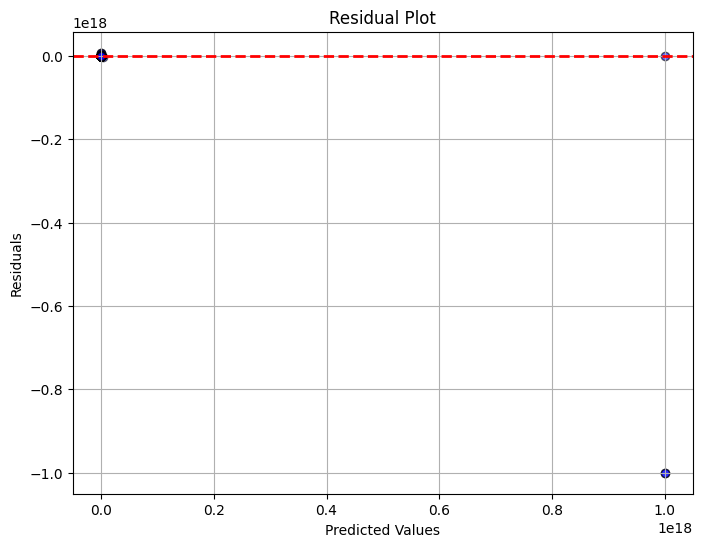

In [28]:
tag_metrics = evaluate_classification(test_ground_truths['tag'], test_predictions['tag'], 'tag')
time_metrics = evaluate_classification(test_ground_truths['time'], test_predictions['time'], 'time')
scale_metrics = evaluate_classification(test_ground_truths['scale'], test_predictions['scale'], 'scale')
negative_metrics = evaluate_classification(test_ground_truths['negative'], test_predictions['negative'], 'negative')
fact_metrics = evaluate_regression(test_ground_truths['fact'], test_predictions['fact'], 'fact')

#### scale & fact evaluation

In [39]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_scale(scale_true, scale_preds):
    scale_acc = accuracy_score(scale_true, scale_preds)
    scale_f1 = f1_score(scale_true, scale_preds, average='macro')
    
    print(f"Scale Accuracy: {scale_acc:.4f}")
    print(f"Scale F1-score: {scale_f1:.4f}")
    
    return scale_acc, scale_f1


In [40]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_fact(fact_true, fact_preds, scale_true, scale_preds):
    # 轉換為 NumPy 陣列
    fact_true = np.asarray(fact_true)
    fact_preds = np.asarray(fact_preds)
    scale_true = np.asarray(scale_true)
    scale_preds = np.asarray(scale_preds)

    # 確保 fact 和 scale 的長度一致
    valid_mask = (scale_true != -100)  # 過濾無效 scale

    fact_true = fact_true[valid_mask]
    fact_preds = fact_preds[valid_mask]
    scale_true = scale_true[valid_mask]
    scale_preds = scale_preds[valid_mask]

    # 確保篩選後的長度相同
    if len(fact_true) != len(scale_true):
        print(f"Error: Mismatch in lengths after filtering! fact_true={len(fact_true)}, scale_true={len(scale_true)}")
        return None

    # 計算 scale 預測是否正確
    correct_scale_mask = (scale_preds == scale_true)  # Scale 預測正確的 mask
    incorrect_scale_mask = ~correct_scale_mask  # Scale 預測錯誤的 mask

    # 計算 RMSE、MAE、R²
    rmse = mean_squared_error(fact_true, fact_preds, squared=False)  # Root MSE
    mae = mean_absolute_error(fact_true, fact_preds)
    r2 = r2_score(fact_true, fact_preds)

    # 當 scale 預測正確時
    if correct_scale_mask.sum() > 0:
        rmse_correct = mean_squared_error(fact_true[correct_scale_mask], fact_preds[correct_scale_mask], squared=False)
        print(f"Fact RMSE (scale correct)  : {rmse_correct:.4f}")
    else:
        rmse_correct = None

    # 當 scale 預測錯誤時
    if incorrect_scale_mask.sum() > 0:
        rmse_incorrect = mean_squared_error(fact_true[incorrect_scale_mask], fact_preds[incorrect_scale_mask], squared=False)
        print(f"Fact RMSE (scale incorrect): {rmse_incorrect:.4f}")
    else:
        rmse_incorrect = None

    print(f"Fact RMSE: {rmse:.4f}")
    print(f"Fact MAE: {mae:.4f}")
    print(f"Fact R²: {r2:.4f}")

    return rmse, mae, r2, rmse_correct, rmse_incorrect


In [41]:
# 先評估 scale 預測
scale_acc, scale_f1 = evaluate_scale(test_ground_truths['scale'], test_predictions['scale'])

# 再評估 fact 預測
evaluate_fact(test_ground_truths['fact'], test_predictions['fact'], test_ground_truths['scale'], test_predictions['scale'])

Scale Accuracy: 0.8526
Scale F1-score: 0.7725
Fact RMSE (scale correct)  : 31521347794136039159360687446280896512.0000
Fact RMSE (scale incorrect): 80768169519553778473329826317379567616.0000
Fact RMSE: 35229971212179200362764151943799504896.0000
Fact MAE: 3647414812645012941180847858309398528.0000
Fact R²: -0.0108


(3.52299712121792e+37,
 3.647414812645013e+36,
 -0.010834926704907932,
 3.152134779413604e+37,
 8.076816951955378e+37)

In [ ]:
# 0131_9
（把 tag 數量減少惹）
TAG Evaluation Metrics:
Accuracy: 0.8160
Precision: 0.6085
Recall: 0.6242
F1 Score: 0.6039

TIME Evaluation Metrics:
Accuracy: 0.8072
Precision: 0.7009
Recall: 0.5939
F1 Score: 0.6234

SCALE Evaluation Metrics:
Accuracy: 0.9744
Precision: 0.8099
Recall: 0.8275
F1 Score: 0.8181

FACT Regression Metrics:
MSE: 14419815709108256768.0000
RMSE: 3797343243.5202
MAE: 734870517.5651
R² Score: -0.0377

In [ ]:
# 0130_6
# Tag weight 2
TAG Evaluation Metrics:
Accuracy: 0.8172
Precision: 0.6161
Recall: 0.6315
F1 Score: 0.6109

TIME Evaluation Metrics:
Accuracy: 0.7998
Precision: 0.6856
Recall: 0.5915
F1 Score: 0.6151

SCALE Evaluation Metrics:
Accuracy: 0.9726
Precision: 0.8095
Recall: 0.8245
F1 Score: 0.8165

In [ ]:
# 0128_5
TAG Evaluation Metrics:
Accuracy: 0.7973
Precision: 0.5308
Recall: 0.5635
F1 Score: 0.5303

TIME Evaluation Metrics:
Accuracy: 0.8178
Precision: 0.7278
Recall: 0.6060
F1 Score: 0.6424

SCALE Evaluation Metrics:
Accuracy: 0.9744
Precision: 0.8099
Recall: 0.8267
F1 Score: 0.8177

In [ ]:
TAG Evaluation Metrics:
Accuracy: 0.7929
Precision: 0.5291
Recall: 0.5459
F1 Score: 0.5210

TIME Evaluation Metrics:
Accuracy: 0.8110
Precision: 0.7312
Recall: 0.5957
F1 Score: 0.6358

SCALE Evaluation Metrics:
Accuracy: 0.9750
Precision: 0.8083
Recall: 0.8286
F1 Score: 0.8175

TAG Evaluation Metrics:
Accuracy: 0.7736
Precision: 0.5500
Recall: 0.5728
F1 Score: 0.5470

TIME Evaluation Metrics:
Accuracy: 0.7745
Precision: 0.6815
Recall: 0.6142
F1 Score: 0.6327
​